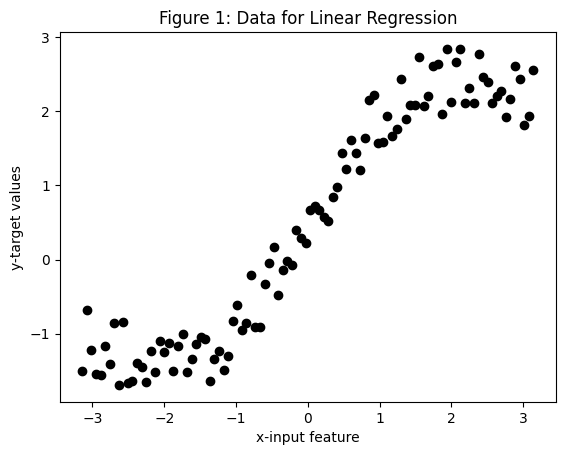

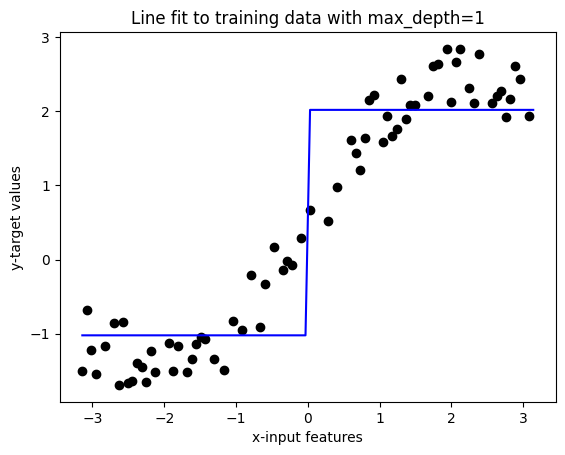

Training MSE:  0.31178774039112894

Validation MSE:  0.4712568280417989

Test MSE:  0.5496653717373919


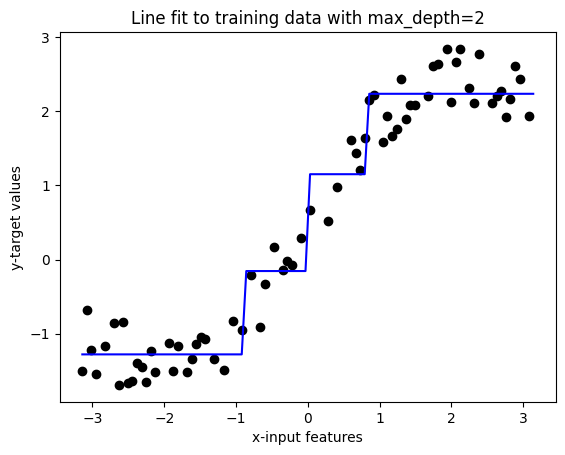

Training MSE:  0.1068516403352611

Validation MSE:  0.1327976170552769

Test MSE:  0.16728563375030478


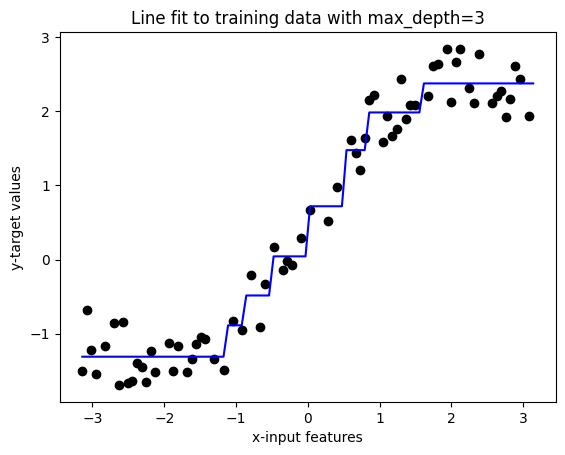

Training MSE:  0.06664819964151635

Validation MSE:  0.08035432711807458

Test MSE:  0.15621469173923952


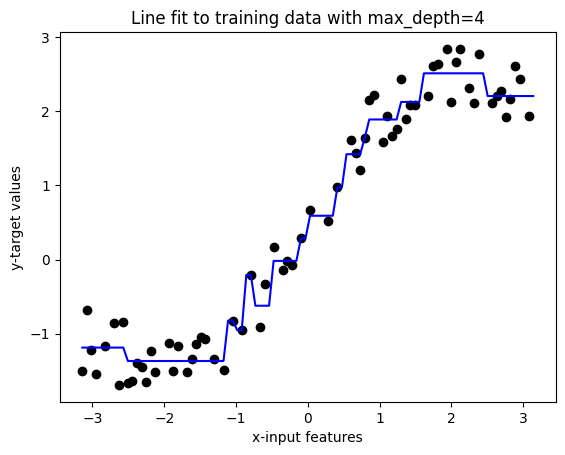

Training MSE:  0.051525711793441675

Validation MSE:  0.08788541006204448

Test MSE:  0.16828481998379774


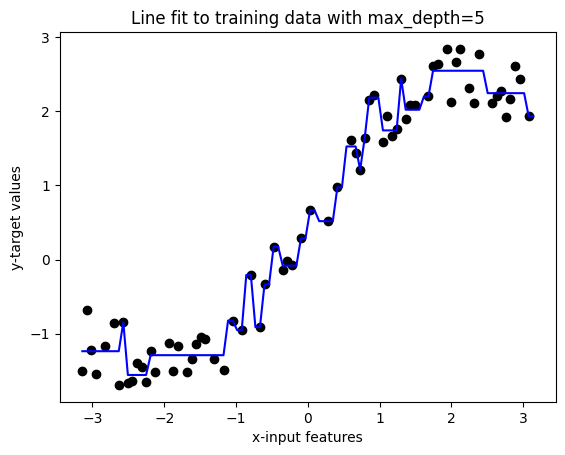

Training MSE:  0.03356873317879478

Validation MSE:  0.12647787861782764

Test MSE:  0.16333604626241088


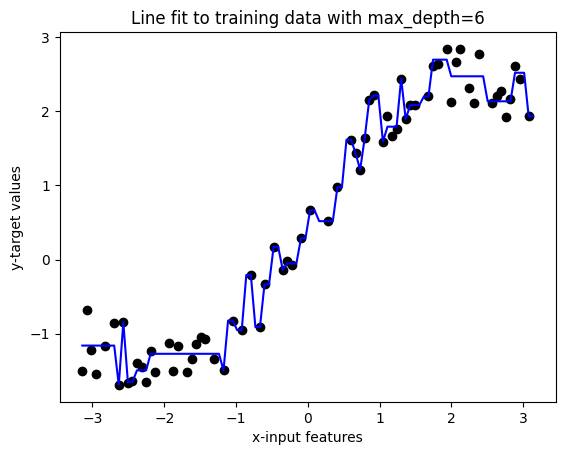

Training MSE:  0.02351143901128185

Validation MSE:  0.1595122667703867

Test MSE:  0.16752509644783647


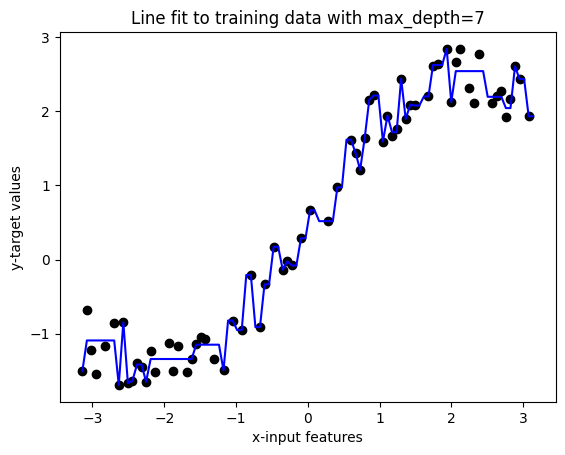

Training MSE:  0.01596102752445567

Validation MSE:  0.1707500515168419

Test MSE:  0.16579771349121428


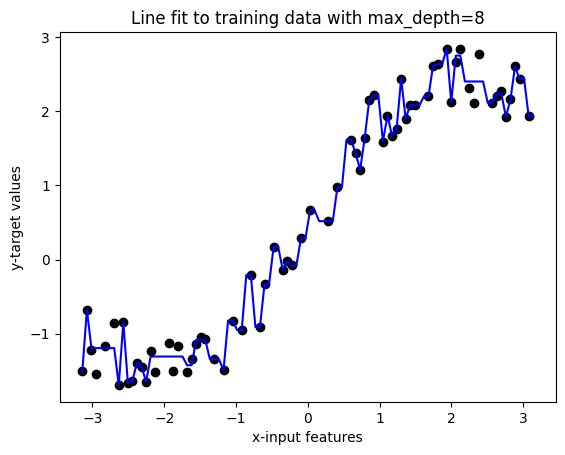

Training MSE:  0.009236405842467016

Validation MSE:  0.14910794145289888

Test MSE:  0.162058342299575


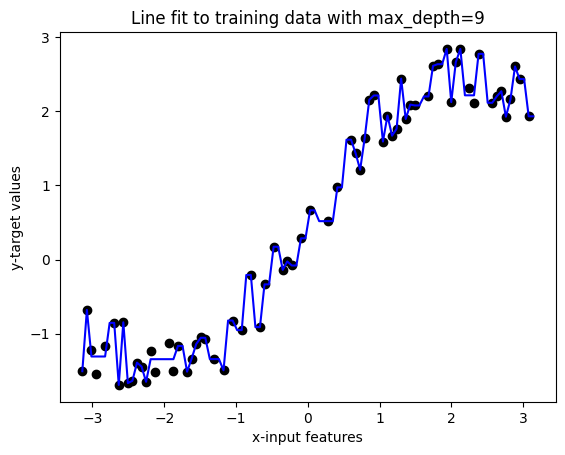

Training MSE:  0.0031523918448051794

Validation MSE:  0.15872077617052313

Test MSE:  0.1635901719914288


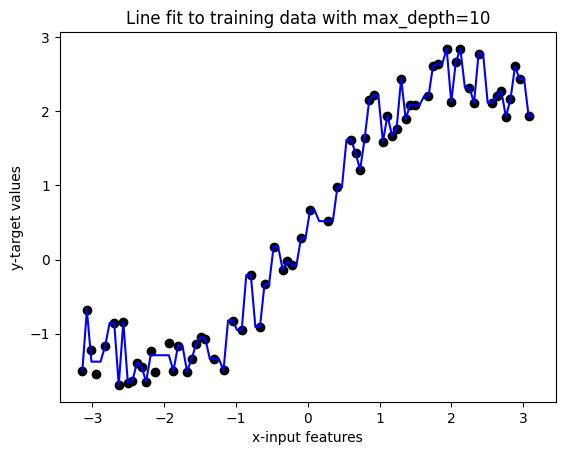

Training MSE:  0.0019514193909085438

Validation MSE:  0.15513226026032093

Test MSE:  0.16522401236009152


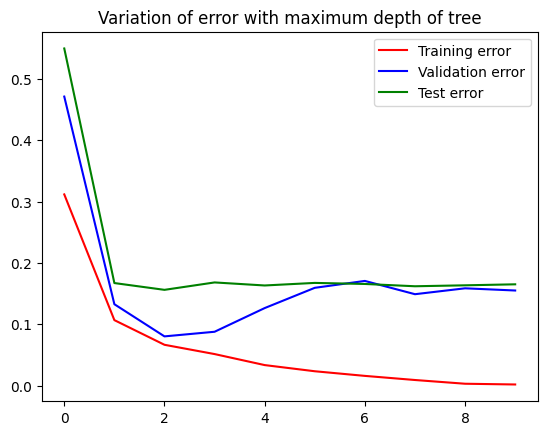

In [1]:
import numpy as np
from sklearn import linear_model, datasets, tree
import matplotlib.pyplot as plt
%matplotlib inline

number_of_samples = 100
x = np.linspace(-np.pi, np.pi, number_of_samples)
y = 0.5*x+np.sin(x)+np.random.random(x.shape)
plt.scatter(x,y,color='black') #Plot y-vs-x in dots
plt.xlabel('x-input feature')
plt.ylabel('y-target values')
plt.title('Figure 1: Data for Linear Regression')
plt.show()

#split= 70-15-15(training-validation-test)
random_indices = np.random.permutation(number_of_samples)
#Training set
x_train = x[random_indices[:70]]
y_train = y[random_indices[:70]]
#Validation set
x_val = x[random_indices[70:85]]
y_val = y[random_indices[70:85]]
#Testing set
x_test = x[random_indices[85:]]
y_test = y[random_indices[85:]]

maximum_depth_of_tree = np.arange(10)+1
train_err_arr = []
val_err_arr = []
test_err_arr = []

for depth in maximum_depth_of_tree:
    model = tree.DecisionTreeRegressor(max_depth=depth)

    x_train_for_line_fitting = np.asarray(x_train.reshape(len(x_train),1))
    y_train_for_line_fitting = np.asarray(y_train.reshape(len(y_train),1))

    model.fit(x_train_for_line_fitting,y_train_for_line_fitting)
    plt.scatter(x_train,y_train, color='black')
    plt.plot(x.reshape((len(x),1)),model.predict(x.reshape((len(x),1))),color='blue')
    plt.xlabel('x-input features')
    plt.ylabel('y-target values')
    plt.title('Line fit to training data with max_depth='+str(depth))
    plt.show()

    mean_train_error = np.mean( (y_train - model.predict(x_train.reshape(len(x_train),1)))**2 )
    mean_val_error = np.mean( (y_val - model.predict(x_val.reshape(len(x_val),1)))**2 )
    mean_test_error = np.mean( (y_test - model.predict(x_test.reshape(len(x_test),1)))**2 )
    
    train_err_arr.append(mean_train_error)
    val_err_arr.append(mean_val_error)
    test_err_arr.append(mean_test_error)

    print ('Training MSE: ', mean_train_error)
    print('\nValidation MSE: ', mean_val_error) 
    print('\nTest MSE: ', mean_test_error)
    
plt.figure()
plt.plot(train_err_arr,c='red')
plt.plot(val_err_arr,c='blue')
plt.plot(test_err_arr,c='green')
plt.legend(['Training error', 'Validation error', 'Test error'])
plt.title('Variation of error with maximum depth of tree')
plt.show()